In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

Matplotlib is building the font cache; this may take a moment.


In [7]:
# Load all 8 CSVs and concatenate
data_dir = Path("../data/CICIDS2017/MachineLearningCVE")

files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

dfs = []
for f in files:
    df_part = pd.read_csv(data_dir / f, encoding='utf-8', low_memory=False)
    print(f"{f}: {df_part.shape}")
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

# Strip whitespace from column names — known CICIDS2017 issue
df.columns = df.columns.str.strip()

print(f"\nFull dataset shape: {df.shape}")

Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)

Full dataset shape: (2830743, 79)


In [8]:
# Per-feature statistics
numeric_cols = df.select_dtypes(include=[np.number]).columns

stats = df[numeric_cols].describe().T
stats['% null'] = (df[numeric_cols].isnull().mean() * 100).round(2)
stats = stats[['min', 'max', 'mean', 'std', '% null']]

print(stats)

# Save for reference
stats.to_csv("../data/eda_cicids2017_stats.csv")

/Users/alyssarusk/GitHub/ML-Based-Network-Intrusion-Detection-Systems/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/alyssarusk/GitHub/ML-Based-Network-Intrusion-Detection-Systems/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                                 min            max          mean  \
Destination Port              0.0000     65535.0000     8071.4825   
Flow Duration               -13.0000 119999998.0000 14785663.9295   
Total Fwd Packets             1.0000    219759.0000        9.3612   
Total Backward Packets        0.0000    291922.0000       10.3938   
Total Length of Fwd Packets   0.0000  12900000.0000      549.3024   
...                              ...            ...           ...   
Active Min                    0.0000 110000000.0000    58295.8177   
Idle Mean                     0.0000 120000000.0000  8316036.6272   
Idle Std                      0.0000  76900000.0000   503843.9498   
Idle Max                      0.0000 120000000.0000  8695751.9846   
Idle Min                      0.0000 120000000.0000  7920031.0146   

                                      std  % null  
Destination Port               18283.6322  0.0000  
Flow Duration               33653744.0859  0.0000  
Total Fwd Packe

Label counts:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Label percentages:
Label
BENIGN                       80.3000
DoS Hulk                      8.1600
PortScan                      5.6100
DDoS                          4.5200
DoS GoldenEye                 0.3600
FTP-Patator                   0.2800
SSH-Patator                   0.2100
DoS slowloris                 0.2000
DoS Slowhttptest              0.1900
Bot                      

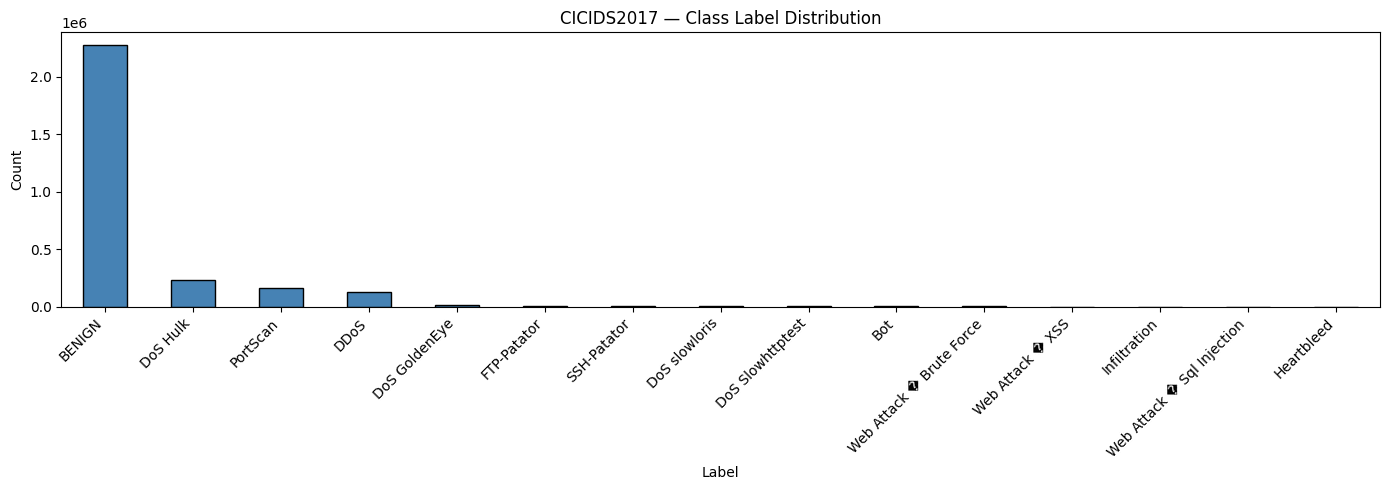

In [9]:
# Class label distribution
label_col = 'Label'

counts = df[label_col].value_counts()
pcts = (counts / len(df) * 100).round(2)

print("Label counts:")
print(counts)
print("\nLabel percentages:")
print(pcts)

plt.figure(figsize=(14, 5))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('CICIDS2017 — Class Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../data/eda_cicids2017_label_dist.png", dpi=150)
plt.show()

In [10]:
# Constant features (zero variance)
constant_features = [col for col in numeric_cols if df[col].nunique() <= 1]

print(f"Constant features ({len(constant_features)}):")
for col in constant_features:
    print(f"  {col}  —  value: {df[col].unique()}")

Constant features (8):
  Bwd PSH Flags  —  value: [0]
  Bwd URG Flags  —  value: [0]
  Fwd Avg Bytes/Bulk  —  value: [0]
  Fwd Avg Packets/Bulk  —  value: [0]
  Fwd Avg Bulk Rate  —  value: [0]
  Bwd Avg Bytes/Bulk  —  value: [0]
  Bwd Avg Packets/Bulk  —  value: [0]
  Bwd Avg Bulk Rate  —  value: [0]


In [11]:
# Duplicate rows
n_dupes = df.duplicated().sum()
pct_dupes = (n_dupes / len(df) * 100).round(2)

print(f"Duplicate rows: {n_dupes} ({pct_dupes}%)")
print("\nSample of duplicates:")
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

Duplicate rows: 308381 (10.89%)

Sample of duplicates:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1919300,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1955871,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1977287,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1983724,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1988456,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2021563,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2045310,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2047742,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0,0,-1,-1,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2060510,0,1,2,0,0,0,0,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,2000000.0000,1.0000,0.0000,1,1,1,1.0000,0.0000,1,1,0,0.0000,0.0000,0,0,0,0,0,0,0,0,2000000.0000,0.0000,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,2,0,0

In [12]:
# Infinite values (another known CICIDS2017 issue)
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_counts = inf_counts[inf_counts > 0]

print("Columns with infinite values:")
print(inf_counts)

Columns with infinite values:
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64
